# Final Pipeline Notebook

This notebook implements the full project lifecycle for diabetic 30-day readmission risk analysis. It imports reusable functions from `src/processing.py`, performs web scraping for medication augmentation, audits the combined dataset, conducts exploratory analysis, and trains a modeling pipeline.

In [37]:
import sys
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd()
if not (project_root / 'src').exists() and (project_root.parent / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import src.processing as processing
importlib.reload(processing)
from src.processing import (
    MEDICATION_COLUMNS,
    augment_with_medication_classes,
    analyze_change_effect,
    audit_data,
    build_medication_class_table,
    clean_diabetes_data,
    load_data,
    save_cleaned_data,
    scrape_medication_summaries_parallel,
    scrape_medication_summaries_sequential,
    train_readmission_model,
)

print(f'Using project root: {project_root}')

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8')

Using project root: c:\Users\laila\OneDrive\Desktop\health-project


## Load Dataset from Data Folder

Read the dataset from `data/diabetic_data.csv` and confirm it loads correctly.

In [25]:
raw_df = load_data(str(project_root / 'data' / 'diabetic_data.csv'))
print(f'Loaded dataset with {raw_df.shape[0]} rows and {raw_df.shape[1]} columns.')
raw_df.head(5)

Loaded dataset with 101766 rows and 50 columns.


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Inspect Dataset Structure

Display the first rows, the data shape, data types, and summary statistics for numeric columns.

In [26]:
print('Shape:', raw_df.shape)
print('\nData types:')
print(raw_df.dtypes.head(20))

raw_df.describe(include='all').loc[['count', 'unique', 'top', 'freq']].T.head(10)

Shape: (101766, 50)

Data types:
encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
dtype: object


,count,unique,top,freq
encounter_id,101766.0,NaN,NaN,NaN
patient_nbr,101766.0,NaN,NaN,NaN
race,101766,6,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
weight,101766,10,?,98569
admission_type_id,101766.0,NaN,NaN,NaN
discharge_disposition_id,101766.0,NaN,NaN,NaN
admission_source_id,101766.0,NaN,NaN,NaN
time_in_hospital,101766.0,NaN,NaN,NaN


## Clean and Prepare Data

Transform columns into model-ready formats, encode medication flags, and prepare the target variable for 30-day readmission prediction.

In [27]:
clean_df = clean_diabetes_data(raw_df)
print('Cleaned shape:', clean_df.shape)
clean_df[['age_years', 'change_flag', 'diabetesMed_flag', 'readmitted_30']].head(5)

Cleaned shape: (101766, 54)


,age_years,change_flag,diabetesMed_flag,readmitted_30
0,5.0,0,0,0
1,15.0,1,1,0
2,25.0,0,1,0
3,35.0,1,1,0
4,45.0,1,1,0


## Data Scraping & Augmentation

Use web scraping to collect supplementary medication information and compare sequential vs. parallel scraping performance.

In [28]:
print('Medication columns to augment:')
print(MEDICATION_COLUMNS)

sequential_summaries, sequential_time = scrape_medication_summaries_sequential(MEDICATION_COLUMNS)
parallel_summaries, parallel_time = scrape_medication_summaries_parallel(MEDICATION_COLUMNS)

print(f'Sequential scraping time: {sequential_time:.2f} seconds')
print(f'Parallel scraping time:   {parallel_time:.2f} seconds')

med_class_table = build_medication_class_table(parallel_summaries)
med_class_table.head(10)

Medication columns to augment:
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Sequential scraping time: 21.14 seconds
Parallel scraping time:   6.55 seconds


,drug,summary,med_class
0,metformin,,Unknown
1,repaglinide,Repaglinideis anantidiabetic drugin the class ...,Insulin
2,nateglinide,"Nateglinide(INN, trade nameStarlix) is adrugfo...",Meglitinide
3,chlorpropamide,"Chlorpropamideis adiabetes medication, belongi...",Sulfonylurea
4,glimepiride,,Unknown
5,acetohexamide,Acetohexamide(trade nameDymelor) is a first-ge...,Sulfonylurea
6,glipizide,,Unknown
7,glyburide,,Unknown
8,tolbutamide,,Unknown
9,pioglitazone,,Unknown


In [29]:
augmented_df = augment_with_medication_classes(clean_df, med_class_table)
print('Augmented shape:', augmented_df.shape)
augmented_df[[c for c in augmented_df.columns if c.endswith('_count')]].head(5)

Augmented shape: (101766, 57)


,insulin_count,meglitinide_count,sulfonylurea_count
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


## Data Audit

Assess the augmented dataset for missing values, outliers, and schema issues before modeling.

In [30]:
audit_summary = audit_data(augmented_df)
print('Dataset shape:', audit_summary['shape'])
print('\nMissing values (top 20):')
print(pd.Series(audit_summary['missing_counts']).sort_values(ascending=False).head(20))
print('\nOutlier counts (numeric):')
print(pd.Series(audit_summary['outlier_counts']).sort_values(ascending=False).head(20))

Dataset shape: (101766, 57)

Missing values (top 20):
weight                      98569
max_glu_serum               96420
A1Cresult                   84748
gender                          3
encounter_id                    0
age                             0
admission_type_id               0
race                            0
patient_nbr                     0
admission_source_id             0
discharge_disposition_id        0
time_in_hospital                0
payer_code                      0
num_procedures                  0
num_medications                 0
medical_specialty               0
num_lab_procedures              0
number_emergency                0
number_outpatient               0
number_inpatient                0
dtype: int64

Outlier counts (numeric):
diabetesMed_flag            23403
number_outpatient           16739
number_emergency            11383
readmitted_30               11357
discharge_disposition_id     9818
number_inpatient             7049
admission_source_id   

## Exploratory Data Analysis

Compute correlations and use grouping to compare readmission outcomes and the effect of medication changes.

In [31]:
corr_cols = ['age_years', 'time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient', 'number_diagnoses', 'change_flag', 'readmitted_30']
print(augmented_df[corr_cols].corr()['readmitted_30'].sort_values(ascending=False))

readmission_by_change = augmented_df.groupby('change_flag')['readmitted_30'].mean().rename({0: 'No Change', 1: 'Change'})
readmission_by_change

readmitted_30         1.000000
number_inpatient      0.165147
number_diagnoses      0.049524
time_in_hospital      0.044199
num_medications       0.038432
num_lab_procedures    0.020364
change_flag           0.019506
age_years             0.017634
Name: readmitted_30, dtype: float64


change_flag
No Change    0.105908
Change       0.118228
Name: readmitted_30, dtype: float64

## Visualize Key Features

Plot distributions and the relationship between medication change and readmission risk.

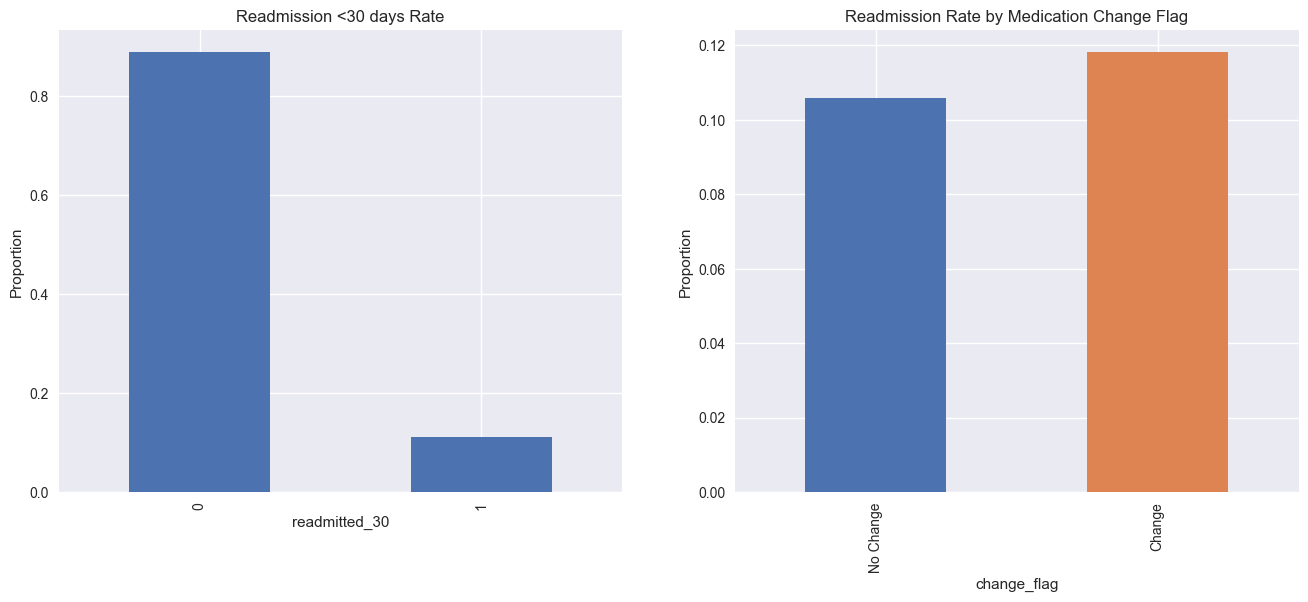

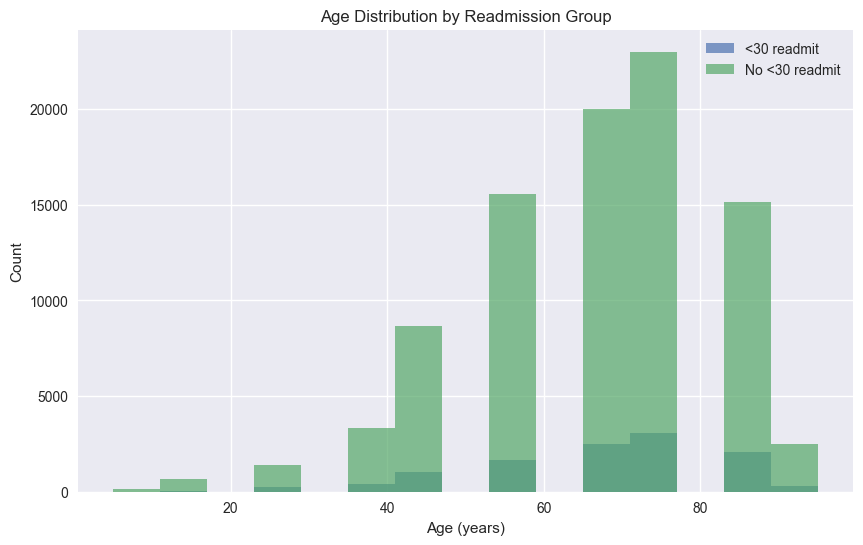

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
augmented_df['readmitted_30'].value_counts(normalize=True).plot(kind='bar', ax=ax[0])
ax[0].set_title('Readmission <30 days Rate')
ax[0].set_ylabel('Proportion')

readmission_by_change.plot(kind='bar', ax=ax[1], color=['#4c72b0', '#dd8452'])
ax[1].set_title('Readmission Rate by Medication Change Flag')
ax[1].set_ylabel('Proportion')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(augmented_df.loc[augmented_df['readmitted_30'] == 1, 'age_years'].dropna(), bins=15, alpha=0.7, label='<30 readmit')
plt.hist(augmented_df.loc[augmented_df['readmitted_30'] == 0, 'age_years'].dropna(), bins=15, alpha=0.7, label='No <30 readmit')
plt.title('Age Distribution by Readmission Group')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.legend()
plt.show()

## Modeling Pipeline

Train a readmission risk model using `sklearn.pipeline`, cross-validation, and hyperparameter tuning.

In [33]:
best_model, model_metrics = train_readmission_model(augmented_df)
print('Best model parameters:')
print(model_metrics['best_params'])
print('\nROC AUC:', model_metrics['roc_auc'])
print('\nConfusion matrix:')
print(model_metrics['confusion_matrix'])
print('\nClassification report:')
print(pd.DataFrame(model_metrics['classification_report']).T)

Best model parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2'}

ROC AUC: 0.6402155645479637

Confusion matrix:
[[18050, 33], [2239, 32]]

Classification report:
              precision    recall  f1-score       support
0              0.889645  0.998175  0.940790  18083.000000
1              0.492308  0.014091  0.027397   2271.000000
accuracy       0.888376  0.888376  0.888376      0.888376
macro avg      0.690976  0.506133  0.484094  20354.000000
weighted avg   0.845312  0.888376  0.838878  20354.000000


c:\Users\laila\OneDrive\Desktop\health-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Medication Change Effect Analysis

Analyze whether medication changes during admission correlate with elevated 30-day readmission risk after controlling for patient severity.

In [34]:
change_effect = analyze_change_effect(augmented_df)
print('Change flag odds ratio:', change_effect['change_flag_odds_ratio'])
print('Logistic coefficients:')
print(change_effect['coefficients'])

Change flag odds ratio: 1.0734353703978468
Logistic coefficients:
{'time_in_hospital': np.float64(0.023293966112325846), 'num_lab_procedures': np.float64(0.0003161353650554699), 'num_medications': np.float64(0.005627009189938186), 'number_inpatient': np.float64(0.28418620535704775), 'age_years': np.float64(0.004912570352811676), 'change_flag': np.float64(0.07086413195781659)}


## Save Processed Data

Export the cleaned and augmented dataset for future use and reproducibility.

In [36]:
cleaned_path = save_cleaned_data(augmented_df, '../data/diabetic_data_cleaned.csv')
print(f'Cleaned dataset saved to: {cleaned_path}')

Cleaned dataset saved to: ../data/diabetic_data_cleaned.csv
